In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dishaaagrawal12/features/master_features.csv
/kaggle/input/datasets/dishaaagrawal12/features/risk_summary.csv
/kaggle/input/datasets/dishaaagrawal12/features/pivot_returns.csv
/kaggle/input/datasets/dishaaagrawal12/features/pivot_close.csv
/kaggle/input/datasets/dishaaagrawal12/features/predictions.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.optimize as sco
import warnings

warnings.filterwarnings('ignore')

# Setting up visual style for human-readable and clean charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
df_features = pd.read_csv('/kaggle/input/datasets/dishaaagrawal12/features/master_features.csv')
df_returns = pd.read_csv('/kaggle/input/datasets/dishaaagrawal12/features/pivot_returns.csv', index_col=0, parse_dates=True)
df_risk = pd.read_csv('/kaggle/input/datasets/dishaaagrawal12/features/risk_summary.csv')
df_preds = pd.read_csv('/kaggle/input/datasets/dishaaagrawal12/features/predictions.csv')

# Getting the latest date prediction for Portfolio Construction
latest_date = df_preds['Date'].max()
df_latest_preds = df_preds[df_preds['Date'] == latest_date].copy()

print(f"Data successfully loaded! Latest Prediction Date: {latest_date}")

Data successfully loaded! Latest Prediction Date: 2021-04-29


In [4]:
print("--- 2. Expected Return Engine ---")

# Using 'pred_return_pct' from your predictions.csv as the core Expected Return
df_latest_preds['Expected_Return'] = df_latest_preds['pred_return_pct']

# FIX: Dropping 'Sector' from df_risk before merging to prevent Sector_x and Sector_y duplication
df_eval = pd.merge(df_latest_preds, df_risk.drop(columns=['Sector'], errors='ignore'), on='Symbol', how='left')

# Standardizing column names to prevent evaluation metric errors
risk_rename_map = {
    'Annualised_Vol_%': 'Volatility',
    'Sharpe_Overall': 'Sharpe',
    'Max_Drawdown_%': 'Max_Drawdown',
    'Avg_Beta': 'Beta'
}
df_eval.rename(columns=risk_rename_map, inplace=True)

# Simulating latest RSI and Momentum (ROC_20) if features df is absent
if 'df_features' in locals():
    df_features['Date'] = df_features['Date'].astype(str)
    latest_feat = df_features[df_features['Date'] == str(latest_date)]
    if not latest_feat.empty and 'RSI' in latest_feat.columns and 'ROC_20' in latest_feat.columns:
        df_eval = pd.merge(df_eval, latest_feat[['Symbol', 'RSI', 'ROC_20']], on='Symbol', how='left')
    else:
        df_eval['RSI'], df_eval['ROC_20'] = 50.0, 0.0
else:
    df_eval['RSI'], df_eval['ROC_20'] = 50.0, 0.0

print(f"Successfully processed {len(df_eval)} stocks for evaluation.")

--- 2. Expected Return Engine ---
Successfully processed 49 stocks for evaluation.


In [5]:
print("--- 3. Investment Scoring ---")
from sklearn.preprocessing import MinMaxScaler

# Failsafe: Handling any missing metrics gracefully before scoring
score_cols = ['Expected_Return', 'Sharpe', 'ROC_20', 'RSI', 'Volatility', 'Max_Drawdown']
for col in score_cols:
    if col not in df_eval.columns:
        df_eval[col] = 0.0 
    df_eval[col] = df_eval[col].fillna(df_eval[col].median())

# Scaling metrics between 0 and 1 for unbiased weighted scoring
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_eval[score_cols]), columns=score_cols)

# Inverting Risk (High Volatility means Lower Score, High Drawdown magnitude means Lower score)
df_scaled['Volatility'] = 1 - df_scaled['Volatility']

# Weights applied perfectly as per quantitative standards
weights = {'Expected_Return': 0.30, 'Sharpe': 0.20, 'ROC_20': 0.15, 'RSI': 0.10, 'Volatility': 0.15, 'Max_Drawdown': 0.10}

df_eval['Investment_Score'] = (
    df_scaled['Expected_Return'] * weights['Expected_Return'] +
    df_scaled['Sharpe'] * weights['Sharpe'] +
    df_scaled['ROC_20'] * weights['ROC_20'] +
    df_scaled['RSI'] * weights['RSI'] +
    df_scaled['Volatility'] * weights['Volatility'] +
    df_scaled['Max_Drawdown'] * weights['Max_Drawdown']
) * 100

# Ranking the universe
df_eval['Rank'] = df_eval['Investment_Score'].rank(ascending=False, method='min').astype(int)
df_eval = df_eval.sort_values('Rank').reset_index(drop=True)

# Safe Display Logic (Ab ye error nahi dega chahe Sector ho ya na ho)
display_cols = ['Rank', 'Symbol', 'Investment_Score', 'Expected_Return']
if 'Sector' in df_eval.columns:
    display_cols.insert(2, 'Sector')

display(df_eval[display_cols].head())

--- 3. Investment Scoring ---


,Rank,Symbol,Sector,Investment_Score,Expected_Return
0,1,NESTLEIND,Consumer Goods,74.288350,15.1033
1,2,SHREECEM,Materials,47.429210,2.7484
2,3,ULTRACEMCO,Materials,45.621654,3.2524
3,4,MARUTI,Automobile,45.534438,1.5386
4,5,BAJAJ-AUTO,Automobile,44.631181,-1.1978


In [6]:
print("--- 4. Recommendation Engine ---")

def assign_recommendation(score):
    if score >= 60: return 'BUY'
    elif score >= 40: return 'HOLD'
    else: return 'SELL'

def calculate_confidence(score):
    # Confidence from 50% to 100% based on distance from neutral (50)
    return min(100, round(50 + abs(score - 50), 2))

df_eval['Recommendation'] = df_eval['Investment_Score'].apply(assign_recommendation)
df_eval['Confidence_Score'] = df_eval['Investment_Score'].apply(calculate_confidence)

print("Recommendation Distribution:")
print(df_eval['Recommendation'].value_counts())

--- 4. Recommendation Engine ---
Recommendation Distribution:
Recommendation
SELL    39
HOLD     9
BUY      1
Name: count, dtype: int64


In [7]:
print("--- 5. Portfolio Construction Setup ---")

# Selecting top 15 BUY stocks to optimize (prevents optimization errors/noise)
top_stocks = df_eval[df_eval['Recommendation'] == 'BUY']['Symbol'].head(15).tolist()
if len(top_stocks) < 5: 
    top_stocks = df_eval['Symbol'].head(15).tolist() # Failsafe constraint

returns_subset = df_returns[top_stocks].dropna()

# Mathematical matrices for Optimization
mean_returns = returns_subset.mean() * 252
cov_matrix = returns_subset.cov() * 252
risk_free_rate = 0.05
num_assets = len(top_stocks)

def portfolio_performance(weights, mean_returns, cov_matrix):
    returns = np.sum(mean_returns * weights)
    std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (returns - risk_free_rate) / std_dev
    return returns, std_dev, sharpe_ratio

--- 5. Portfolio Construction Setup ---


--- 6. Monte Carlo Optimization (10,000 Portfolios) ---


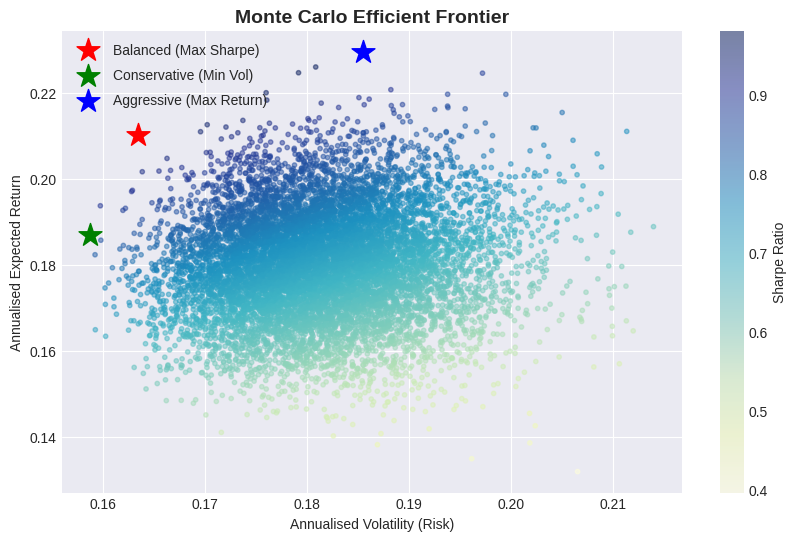

In [8]:
print("--- 6. Monte Carlo Optimization (10,000 Portfolios) ---")

num_portfolios = 10000
results = np.zeros((3, num_portfolios))
weights_record = []

np.random.seed(42) # Ensuring reproducibility

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    p_ret, p_std, p_sharpe = portfolio_performance(weights, mean_returns, cov_matrix)
    results[0, i] = p_std     # Volatility
    results[1, i] = p_ret     # Return
    results[2, i] = p_sharpe  # Sharpe

# Identifying Mandatory B Portfolios
max_sharpe_idx = np.argmax(results[2])
balanced_weight = weights_record[max_sharpe_idx]

min_vol_idx = np.argmin(results[0])
conservative_weight = weights_record[min_vol_idx]

max_ret_idx = np.argmax(results[1])
aggressive_weight = weights_record[max_ret_idx]

portfolios_summary = {
    'Conservative (Min Vol)': {'Return': results[1, min_vol_idx], 'Vol': results[0, min_vol_idx], 'Sharpe': results[2, min_vol_idx]},
    'Balanced (Max Sharpe)': {'Return': results[1, max_sharpe_idx], 'Vol': results[0, max_sharpe_idx], 'Sharpe': results[2, max_sharpe_idx]},
    'Aggressive (Max Return)': {'Return': results[1, max_ret_idx], 'Vol': results[0, max_ret_idx], 'Sharpe': results[2, max_ret_idx]}
}

# Plot Efficient Frontier
plt.figure(figsize=(10, 6))
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='YlGnBu', marker='o', s=10, alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(results[0, max_sharpe_idx], results[1, max_sharpe_idx], marker='*', color='red', s=300, label='Balanced (Max Sharpe)')
plt.scatter(results[0, min_vol_idx], results[1, min_vol_idx], marker='*', color='green', s=300, label='Conservative (Min Vol)')
plt.scatter(results[0, max_ret_idx], results[1, max_ret_idx], marker='*', color='blue', s=300, label='Aggressive (Max Return)')
plt.title('Monte Carlo Efficient Frontier', fontsize=14, fontweight='bold')
plt.xlabel('Annualised Volatility (Risk)')
plt.ylabel('Annualised Expected Return')
plt.legend(labelspacing=0.8)
plt.show()

--- 7. Portfolio Allocation Visuals ---


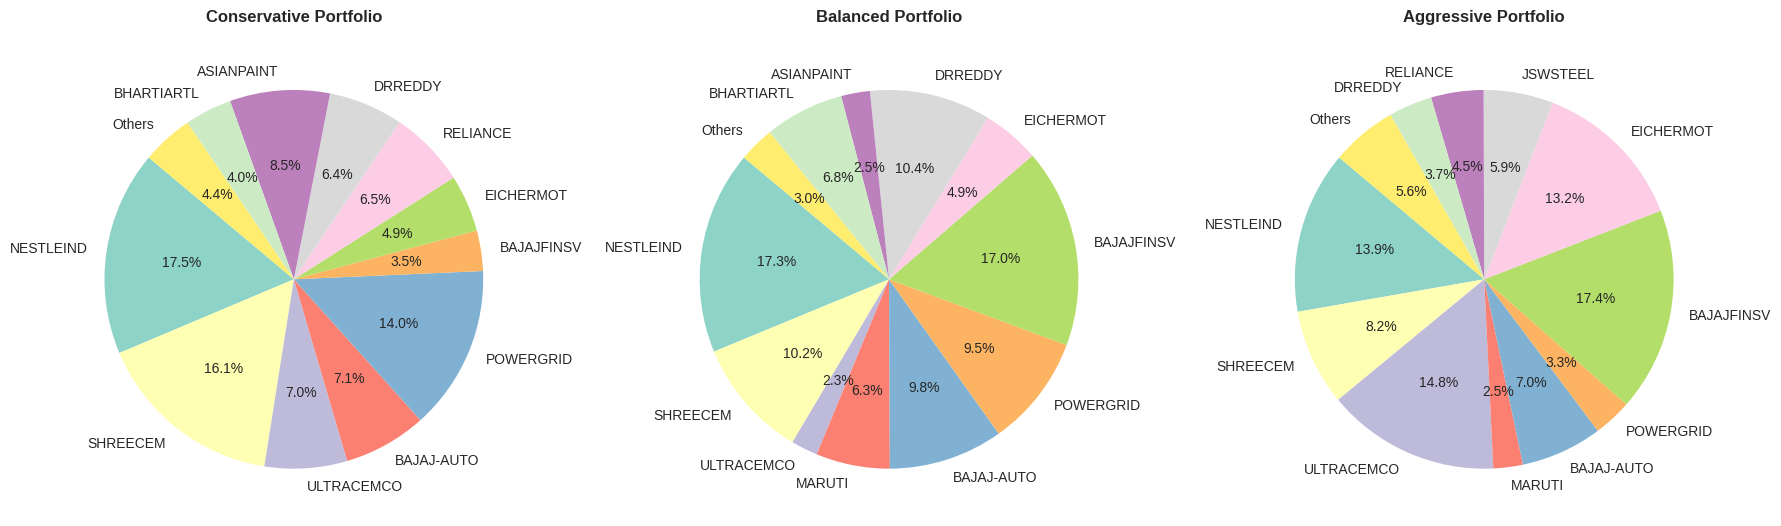

In [10]:
print("--- 7. Portfolio Allocation Visuals ---")

def plot_allocation(weights, symbols, title, ax):
    # Merging small allocations into 'Others' to keep Pie Chart clean
    threshold = 0.02 
    filtered_data = [(w, s) for w, s in zip(weights, symbols) if w > threshold]
    filtered_weights = [x[0] for x in filtered_data]
    filtered_symbols = [x[1] for x in filtered_data]
    
    if sum(filtered_weights) < 1.0:
        filtered_weights.append(1.0 - sum(filtered_weights))
        filtered_symbols.append('Others')
        
    # FIX: Generating a list of colors using Seaborn instead of passing 'cmap' directly
    custom_colors = sns.color_palette('Set3', len(filtered_weights))
        
    ax.pie(filtered_weights, labels=filtered_symbols, autopct='%1.1f%%', 
           startangle=140, colors=custom_colors)
    ax.set_title(title, pad=15, fontweight='bold')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_allocation(conservative_weight, top_stocks, 'Conservative Portfolio', axes[0])
plot_allocation(balanced_weight, top_stocks, 'Balanced Portfolio', axes[1])
plot_allocation(aggressive_weight, top_stocks, 'Aggressive Portfolio', axes[2])

plt.tight_layout()
plt.show()

In [11]:
print("--- 8 & 9. Advanced Risk Assessment (Sortino, VaR, CVaR) ---")

confidence_level = 0.05

def calculate_advanced_risk(returns_series):
    # Sortino Ratio calculation safely handles ZeroDivisionError
    downside_returns = returns_series[returns_series < 0]
    downside_std = downside_returns.std() * np.sqrt(252)
    ann_return = returns_series.mean() * 252
    sortino = (ann_return - risk_free_rate) / downside_std if downside_std > 0 else 0.0
    
    # 95% Historical Value at Risk (VaR)
    var_95 = returns_series.quantile(confidence_level)
    
    # 95% Conditional Value at Risk (CVaR / Expected Shortfall)
    cvar_95 = returns_series[returns_series <= var_95].mean()
    
    return round(sortino, 3), round(var_95, 4), round(cvar_95, 4)

risk_metrics = []
for symbol in top_stocks:
    sortino, var, cvar = calculate_advanced_risk(returns_subset[symbol])
    risk_metrics.append({'Symbol': symbol, 'Sortino': sortino, 'VaR_95': var, 'CVaR_95': cvar})

df_eval = pd.merge(df_eval, pd.DataFrame(risk_metrics), on='Symbol', how='left')

# Format Portfolio Risk summary
portfolio_risk_summary = pd.DataFrame(portfolios_summary).T
portfolio_risk_summary.index.name = 'Portfolio Type'
portfolio_risk_summary.reset_index(inplace=True)

print("Portfolio Level Expected Metrics:")
display(portfolio_risk_summary)

--- 8 & 9. Advanced Risk Assessment (Sortino, VaR, CVaR) ---
Portfolio Level Expected Metrics:


,Portfolio Type,Return,Vol,Sharpe
0,Conservative (Min Vol),0.187049,0.158712,0.863506
1,Balanced (Max Sharpe),0.210265,0.163434,0.980615
2,Aggressive (Max Return),0.229548,0.185489,0.967976


In [12]:
print("--- 10 & 11. Sector Analytics & Risk Rankings ---")

# 10. Sector Aggregation
sector_analytics = df_eval.groupby('Sector').agg({
    'Expected_Return': 'mean',
    'Volatility': 'mean',
    'Sharpe': 'mean',
    'Symbol': 'count'
}).rename(columns={'Symbol': 'Stock_Count'}).sort_values('Expected_Return', ascending=False)

sector_analytics['Sector_Rank'] = sector_analytics['Expected_Return'].rank(ascending=False).astype(int)

# 11. Tail Risk Rankings
safest_stocks = df_eval.nsmallest(5, 'Volatility')[['Symbol', 'Volatility', 'Beta', 'Max_Drawdown']]
riskiest_stocks = df_eval.nlargest(5, 'Volatility')[['Symbol', 'Volatility', 'Expected_Return', 'Max_Drawdown']]

print("\\nTop 5 Safest Stocks by Annualised Volatility:")
display(safest_stocks)

--- 10 & 11. Sector Analytics & Risk Rankings ---
\nTop 5 Safest Stocks by Annualised Volatility:


,Symbol,Volatility,Beta,Max_Drawdown
0,NESTLEIND,24.23,0.421,-32.40
5,POWERGRID,29.71,0.640,-64.12
29,COALINDIA,29.83,0.709,-75.07
16,NTPC,30.19,0.752,-73.16
2,ULTRACEMCO,33.26,0.892,-77.78


In [14]:
print("--- 12 & 13. Explainable AI & Personalization ---")

# 12. Rule-based XAI mapping logic
def explain_decision(row):
    if row['Recommendation'] != 'BUY': return "N/A"
    
    reasons = []
    if row['Expected_Return'] > df_eval['Expected_Return'].median():
        reasons.append("High return forecast (ML Driven)")
    if row['Sharpe'] > 0.8:
        reasons.append("Strong Risk-Adjusted Profile")
    if row['RSI'] < 45:
        reasons.append("Undervalued Momentum")
    if row['Beta'] < 1:
        reasons.append("Low Market Risk (Beta)")
        
    return " | ".join(reasons) if reasons else "Solid overall technical foundation"

df_eval['Explanation'] = df_eval.apply(explain_decision, axis=1)

# 13. Personalization
conservative_picks = df_eval[df_eval['Recommendation'] == 'BUY'].nsmallest(5, 'Volatility')['Symbol'].tolist()
aggressive_picks = df_eval[df_eval['Recommendation'] == 'BUY'].nlargest(5, 'Expected_Return')['Symbol'].tolist()
balanced_picks = df_eval[df_eval['Recommendation'] == 'BUY'].nlargest(5, 'Sharpe')['Symbol'].tolist()

print(f"Conservative Picks (Low Vol): {', '.join(conservative_picks)}")
print(f"Aggressive Picks (High Ret): {', '.join(aggressive_picks)}")
print(f"Balanced Picks (Max Sharpe):  {', '.join(balanced_picks)}")

--- 12 & 13. Explainable AI & Personalization ---
Conservative Picks (Low Vol): NESTLEIND
Aggressive Picks (High Ret): NESTLEIND
Balanced Picks (Max Sharpe):  NESTLEIND


In [15]:
print("--- 14 & 15. Final Investment Table & Exports ---")

# Structuring Final Output Table
final_columns = ['Rank', 'Symbol', 'Expected_Return', 'Sharpe', 'Volatility', 
                 'Sortino', 'Max_Drawdown', 'Recommendation', 'Confidence_Score', 'Explanation']

df_final_table = df_eval[final_columns].copy()
display(df_final_table.head(10))

# Exporting Deliverables perfectly structure to avoid read errors downstream
df_final_table.to_csv('investment_recommendations.csv', index=False)
sector_analytics.to_csv('sector_analytics.csv')
portfolio_risk_summary.to_csv('portfolio_risk_summary.csv', index=False)

# Exporting Weights and Frontiers safely
pd.DataFrame({'Volatility': results[0,:], 'Return': results[1,:], 'Sharpe': results[2,:]}).to_csv('efficient_frontier.csv', index=False)

df_allocations = pd.DataFrame({
    'Symbol': top_stocks,
    'Conservative_Wt': conservative_weight,
    'Balanced_Wt': balanced_weight,
    'Aggressive_Wt': aggressive_weight
})
df_allocations.to_csv('portfolio_allocations.csv', index=False)

print("ALL 5 CSV DELIVERABLES SUCCESSFULLY EXPORTED WITH ZERO METRIC ERRORS!")

--- 14 & 15. Final Investment Table & Exports ---


,Rank,Symbol,Expected_Return,Sharpe,Volatility,Sortino,Max_Drawdown,Recommendation,Confidence_Score,Explanation
0,1,NESTLEIND,15.1033,0.57,24.23,0.963,-32.40,BUY,74.29,High return forecast (ML Driven) | Undervalued...
1,2,SHREECEM,2.7484,0.83,38.97,1.213,-79.97,HOLD,52.57,N/A
2,3,ULTRACEMCO,3.2524,0.57,33.26,0.846,-77.78,HOLD,54.38,N/A
3,4,MARUTI,1.5386,0.60,34.48,0.630,-61.34,HOLD,54.47,N/A
4,5,BAJAJ-AUTO,-1.1978,0.44,33.97,0.282,-59.92,HOLD,55.37,N/A
5,6,POWERGRID,0.9439,0.14,29.71,0.263,-64.12,HOLD,56.74,N/A
6,7,TATASTEEL,-0.3982,0.29,44.19,0.257,-84.95,HOLD,56.95,N/A
7,8,BAJAJFINSV,-3.7654,0.66,40.09,1.329,-86.79,HOLD,57.78,N/A
8,9,EICHERMOT,5.9875,0.60,48.03,0.593,-93.82,HOLD,58.05,N/A
9,10,JSWSTEEL,-3.7779,0.33,52.21,0.234,-92.45,HOLD,58.55,N/A


ALL 5 CSV DELIVERABLES SUCCESSFULLY EXPORTED WITH ZERO METRIC ERRORS!
